In [1]:
import joblib

# โหลด vectorizer
vectorizer = joblib.load('../Features/result/vectorizer.pkl')

# โหลด X_tfidf
X_tfidf = joblib.load('../Features/result/X_tfidf.pkl')

# โหลด y_under
y_under = joblib.load('../InitData/result/y_under.pkl')

print("✅ โหลดข้อมูลเรียบร้อยแล้ว!")


✅ โหลดข้อมูลเรียบร้อยแล้ว!


In [24]:
print(y_under)

[0 0 0 ... 1 1 1]


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model(input_dim):
    model = Sequential()
    model.add(Dense(512, input_dim=input_dim, activation='relu'))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))  # Binary classification
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model



📂 Fold 1


C:\Users\SUPHASET\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

📂 Fold 2
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

📂 Fold 3
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

📂 Fold 4
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

📂 Fold 5
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

✅ Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2245
           1       0.99      0.97      0.98      2000

    accuracy                           0.98      4245
   macro avg       0.98      0.98      0.98      4245
weighted avg       0.98      0.98      0.98      4245

✅ Confusion Matrix:
[[2223   22]
 [  59 1941]]


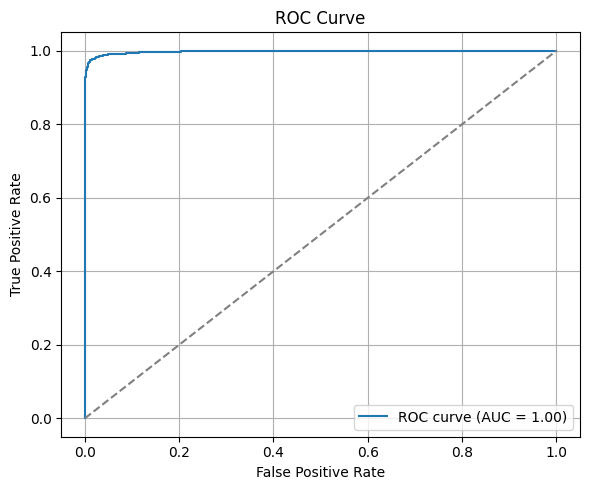

In [3]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ------------------------------
# เตรียมข้อมูล
# ------------------------------
X_dense = X_tfidf.toarray().astype(np.float32)
y = y_under  # Binary: [0, 0, 1, 1, ...]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_y_true = []
all_y_pred = []
all_y_proba = []

# ------------------------------
# Cross-validation loop
# ------------------------------
for fold, (train_idx, val_idx) in enumerate(kf.split(X_dense, y), 1):
    print(f"\n📂 Fold {fold}")

    X_train, X_val = X_dense[train_idx], X_dense[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = build_model(input_dim=X_train.shape[1])  # sigmoid + binary_crossentropy

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2)

    model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    y_val_proba = model.predict(X_val).ravel()
    y_val_pred = (y_val_proba > 0.5).astype(int)

    all_y_true.extend(y_val)
    all_y_pred.extend(y_val_pred)
    all_y_proba.extend(y_val_proba)

# ------------------------------
# รายงานผลรวมทุก fold
# ------------------------------
print("\n✅ Classification Report:")
print(classification_report(all_y_true, all_y_pred))

print("✅ Confusion Matrix:")
print(confusion_matrix(all_y_true, all_y_pred))

# ------------------------------
# ROC Curve
# ------------------------------
fpr, tpr, _ = roc_curve(all_y_true, all_y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [4]:
# บันทึกโมเดลที่ฝึกแล้ว
model.save(f'result/models/model_fold_{fold}.h5')  # Save the model after each fold
print(f"✅ โมเดลที่ฝึกใน fold {fold} ถูกบันทึกแล้ว!")

✅ โมเดลที่ฝึกใน fold 5 ถูกบันทึกแล้ว!
